In [1]:
import kagglehub  # library to download kaggle datasets directly

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")  # download dataset

print("Dataset downloaded to:", path)  # shows the folder where files are extracted

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded to: /kaggle/input/gtsrb-german-traffic-sign


In [2]:
import os  # for listing files and folders

print(os.listdir(path))  # see what's inside the downloaded dataset folder

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [3]:
import pandas as pd  # to read CSV files
import numpy as np  # for array operations
from PIL import Image  # to load and resize images
import matplotlib.pyplot as plt  # for plotting

In [4]:
DATASET_DIR = path  # base folder from kagglehub download (Cell 1 output)

train_df = pd.read_csv(os.path.join(DATASET_DIR, "Train.csv"))  # load training metadata (paths + labels)

IMG_SIZE = 32  # resize all images to 32x32 (standard for GTSRB)

images = []  # will hold image arrays
labels = []  # will hold class labels

for idx, row in train_df.iterrows():  # loop through every row in Train.csv
    img_path = os.path.join(DATASET_DIR, row["Path"])  # full path to each image
    img = Image.open(img_path).convert("RGB")  # open image and force RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))  # resize to fixed size
    images.append(np.array(img))  # convert to array and store
    labels.append(row["ClassId"])  # store corresponding class label

X = np.array(images, dtype="float32") / 255.0  # normalize pixel values to 0-1
y = np.array(labels)  # convert labels list to array

print("X shape:", X.shape)  # sanity check: should be (39209, 32, 32, 3)
print("y shape:", y.shape)  # sanity check: should be (39209,)

X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [5]:
from sklearn.model_selection import train_test_split  # for stratified splitting

X_train, X_val, y_train, y_val = train_test_split(
    X, y,  # our full dataset
    test_size=0.2,  # 20% data for validation
    stratify=y,  # keep class ratio same in both splits
    random_state=42  # fixed seed for reproducibility
)

print("X_train shape:", X_train.shape)  # check training set size
print("X_val shape:", X_val.shape)  # check validation set size

X_train shape: (31367, 32, 32, 3)
X_val shape: (7842, 32, 32, 3)


In [6]:
import tensorflow as tf  # main deep learning library
from tensorflow.keras import layers, models  # to build CNN layers easily

num_classes = 43  # total traffic sign classes

model = models.Sequential([  # simple stack of layers

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),  # first conv block
    layers.BatchNormalization(),  # stabilize training
    layers.MaxPooling2D((2,2)),  # downsample

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),  # second conv block
    layers.BatchNormalization(),  # stabilize training
    layers.MaxPooling2D((2,2)),  # downsample

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),  # third conv block
    layers.BatchNormalization(),  # stabilize training
    layers.MaxPooling2D((2,2)),  # downsample

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),  # fourth conv block
    layers.BatchNormalization(),  # stabilize training

    layers.GlobalAveragePooling2D(),  # replaces Flatten, reduces overfitting

    layers.Dropout(0.4),  # randomly drop neurons to prevent overfitting
    layers.Dense(128, activation='relu'),  # fully connected layer
    layers.Dropout(0.3),  # another dropout before output

    layers.Dense(num_classes, activation='softmax')  # output layer, one score per class
])

model.summary()  # print architecture summary

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,779 (1.64 MB)

 Trainable params: 427,819 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # for smarter training

early_stop = EarlyStopping(
    monitor='val_loss',  # watch validation loss
    patience=5,  # stop if no improvement for 5 epochs
    restore_best_weights=True  # go back to best epoch's weights when stopping
)

checkpoint = ModelCheckpoint(
    "best_baseline_model.keras",  # save best model to this file
    monitor='val_loss',  # based on validation loss
    save_best_only=True  # only keep the best one, not every epoch
)

model.compile(
    optimizer='adam',  # standard optimizer
    loss='sparse_categorical_crossentropy',  # integer labels
    metrics=['accuracy']  # track accuracy
)

history = model.fit(
    X_train, y_train,  # training data
    validation_data=(X_val, y_val),  # validation data
    epochs=30,  # give more room, early stopping will cut it short if needed
    batch_size=64,  # batch size
    callbacks=[early_stop, checkpoint],  # smart stopping + saving
    verbose=1  # show progress
)


best_epoch = early_stop.stopped_epoch - early_stop.patience + 1  # calculate best epoch number

print("Training stopped at epoch:", early_stop.stopped_epoch + 1)  # epoch where training actually stopped
print("Best epoch was:", best_epoch)  # epoch with the best val_loss (weights restored from here)
print("Best val_loss:", min(history.history['val_loss']))  # lowest validation loss achieved
print("Best val_accuracy:", history.history['val_accuracy'][history.history['val_loss'].index(min(history.history['val_loss']))])  # accuracy at that best epoch

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6521 - loss: 1.2556 - val_accuracy: 0.4123 - val_loss: 2.6479
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9570 - loss: 0.1511 - val_accuracy: 0.9584 - val_loss: 0.1293
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9751 - loss: 0.0880 - val_accuracy: 0.9855 - val_loss: 0.0456
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9833 - loss: 0.0581 - val_accuracy: 0.9898 - val_loss: 0.0334
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - loss: 0.0387 - val_accuracy: 0.9847 - val_loss: 0.0533
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9860 - loss: 0.0480 - val_accuracy: 0.9923 - val_loss: 0.0227
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9891 - loss: 0.0363 - val_accuracy: 0.9936 - val_loss: 0.0239
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9921 - loss: 0.0265 - val_accuracy: 

In [8]:
from sklearn.metrics import classification_report  # gives per-class precision/recall/f1

y_pred = model.predict(X_val)  # get predictions on validation set
y_pred_classes = y_pred.argmax(axis=1)  # convert probabilities to class labels

report = classification_report(y_val, y_pred_classes, digits=3)  # per-class metrics
print(report)  # display it

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        42
           1      0.995     0.995     0.995       444
           2      0.996     0.991     0.993       450
           3      1.000     0.993     0.996       282
           4      1.000     0.997     0.999       396
           5      0.989     0.997     0.993       372
           6      1.000     1.000     1.000        84
           7      1.000     0.993     0.997       288
           8      1.000     0.996     0.998       282
           9      1.000     1.000     1.000       294
          10      1.000     1.000     1.000       402
          11      0.974     1.000     0.987       264
          12      1.000     1.000     1.000       420
          13      0.991     1.000     0.995       432
          14      0.994     1.000     0.997       156
          15      1.000     1.000     1.000       126
          16      1.000     1.000     1.

## 5. Evaluate on Test Set

In [9]:
test_df = pd.read_csv(os.path.join(DATASET_DIR, "Test.csv"))  # load test metadata (paths + labels)

test_images = []  # will hold test image arrays
test_labels = []  # will hold test class labels

for idx, row in test_df.iterrows():  # loop through every row in Test.csv
    img_path = os.path.join(DATASET_DIR, row["Path"])  # full path to test image
    img = Image.open(img_path).convert("RGB")  # open image and force RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))  # resize to same size as training
    test_images.append(np.array(img))  # store pixel array
    test_labels.append(row["ClassId"])  # store true label

X_test = np.array(test_images, dtype="float32") / 255.0  # normalize pixel values
y_test = np.array(test_labels)  # convert labels to array

print("X_test shape:", X_test.shape)  # sanity check: should be (12630, 32, 32, 3)
print("y_test shape:", y_test.shape)  # sanity check: should be (12630,)

X_test shape: (12630, 32, 32, 3)
y_test shape: (12630,)


In [10]:
y_test_pred = model.predict(X_test)  # get predictions on test set
y_test_pred_classes = y_test_pred.argmax(axis=1)  # convert probabilities to class labels

test_report = classification_report(y_test, y_test_pred_classes, digits=3)  # per-class metrics
print(test_report)  # display it

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        60
           1      0.978     0.999     0.988       720
           2      0.988     0.991     0.989       750
           3      0.973     0.947     0.959       450
           4      0.998     0.948     0.973       660
           5      0.920     0.984     0.951       630
           6      0.993     0.900     0.944       150
           7      0.974     0.980     0.977       450
           8      0.998     0.936     0.966       450
           9      0.990     0.998     0.994       480
          10      0.998     0.989     0.994       660
          11      0.817     1.000     0.899       420
          12      0.992     0.930     0.960       690
          13      0.936     0.996     0.965       720
          14      0.961     1.000     0.980       270
          15      0.901     1.000     0.948       210
          16      1.000     1.000     1.

In [11]:
from sklearn.metrics import confusion_matrix  # to see which classes get confused with which

cm = confusion_matrix(y_test, y_test_pred_classes)  # full confusion matrix

# check what class 27 is being confused with
class_id = 27  # pedestrians - worst performing class
row = cm[class_id]  # predictions for true class 27
for pred_class, count in enumerate(row):  # loop through predicted classes
    if count > 0:  # only show non-zero confusions
        print(f"True 27 predicted as {pred_class}: {count} times")  # print confusion

True 27 predicted as 11: 27 times
True 27 predicted as 25: 3 times
True 27 predicted as 27: 30 times


In [12]:
class_id = 21  # double curve - also poor performing
row = cm[class_id]  # predictions for true class 21
for pred_class, count in enumerate(row):  # loop through predicted classes
    if count > 0:  # only show non-zero confusions
        print(f"True 21 predicted as {pred_class}: {count} times")  # print confusion

True 21 predicted as 11: 7 times
True 21 predicted as 18: 1 times
True 21 predicted as 21: 59 times
True 21 predicted as 26: 12 times
True 21 predicted as 29: 11 times


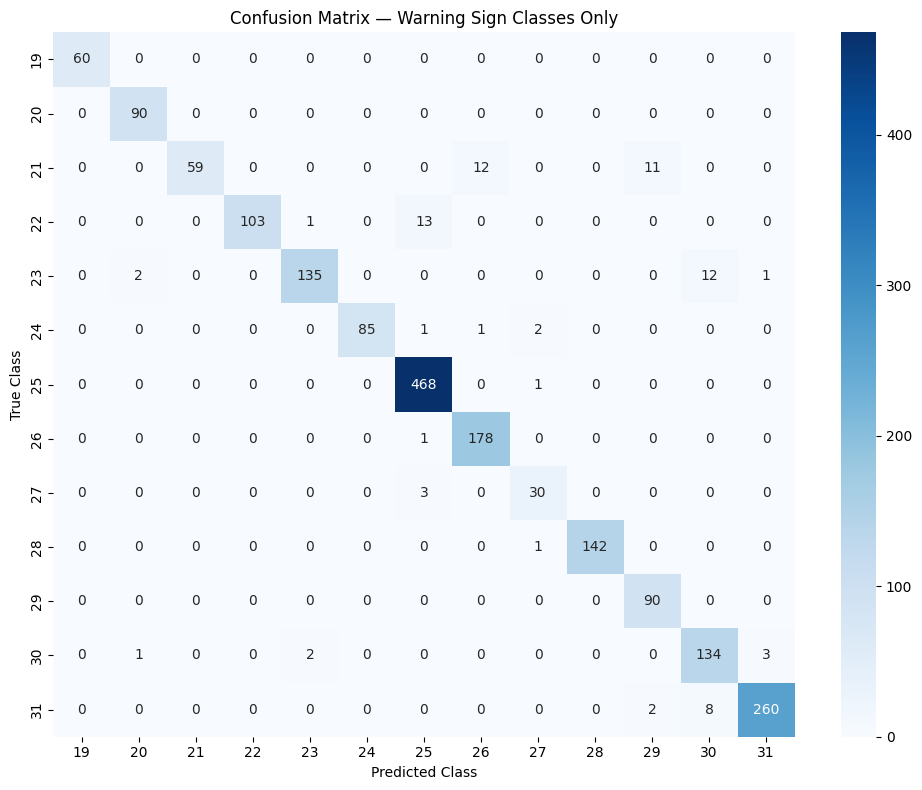

In [13]:
import seaborn as sns  # for heatmap visualization

warning_classes = [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]  # triangular warning sign classes

cm_subset = cm[np.ix_(warning_classes, warning_classes)]  # extract only these rows/columns from full confusion matrix

plt.figure(figsize=(10, 8))  # set figure size
sns.heatmap(cm_subset, annot=True, fmt='d', xticklabels=warning_classes, yticklabels=warning_classes, cmap='Blues')  # draw heatmap with numbers
plt.xlabel("Predicted Class")  # x-axis label
plt.ylabel("True Class")  # y-axis label
plt.title("Confusion Matrix — Warning Sign Classes Only")  # chart title
plt.tight_layout()  # fix spacing
plt.savefig("warning_signs_confusion.png")  # save chart
plt.show()  # display chart

## 6. Treatment 1 — Class-Weighted Loss

In [17]:
from sklearn.utils.class_weight import compute_class_weight  # to calculate balanced class weights

class_weights_array = compute_class_weight(
    class_weight='balanced',  # automatically weight inversely proportional to class frequency
    classes=np.unique(y_train),  # all unique class labels
    y=y_train  # training labels
)

class_weights = dict(enumerate(class_weights_array))  # convert to dictionary format Keras expects

print(class_weights)  # check the weights — rare classes should have higher values

{0: np.float64(4.342054263565892), 1: np.float64(0.41073486276974647), 2: np.float64(0.40525839793281654), 3: np.float64(0.6466889328715157), 4: np.float64(0.460520906741837), 5: np.float64(0.4902319329832458), 6: np.float64(2.171027131782946), 7: np.float64(0.6332162467700259), 8: np.float64(0.6466889328715157), 9: np.float64(0.6202934662236987), 10: np.float64(0.4536474603725558), 11: np.float64(0.6907813601127555), 12: np.float64(0.43420542635658915), 13: np.float64(0.4221441645133506), 14: np.float64(1.169014609421586), 15: np.float64(1.4473514211886305), 16: np.float64(2.171027131782946), 17: np.float64(0.8214697255394929), 18: np.float64(0.759859496124031), 19: np.float64(4.342054263565892), 20: np.float64(2.5328649870801034), 21: np.float64(2.763125440451022), 22: np.float64(2.338029218843172), 23: np.float64(1.787904696762426), 24: np.float64(3.3771533161068046), 25: np.float64(0.6078875968992248), 26: np.float64(1.519718992248062), 27: np.float64(3.799297480620155), 28: np.flo

In [18]:
model_weighted = models.Sequential([  # same architecture as baseline

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model_weighted.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
early_stop_w = EarlyStopping(  # separate early stopping object for this model
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_w = ModelCheckpoint(
    "best_weighted_model.keras",  # different filename from baseline
    monitor='val_loss',
    save_best_only=True
)

history_weighted = model_weighted.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,  # <-- ye naya parameter hai, baseline mein nahi tha
    callbacks=[early_stop_w, checkpoint_w],
    verbose=1
)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.4820 - loss: 1.7275 - val_accuracy: 0.5592 - val_loss: 1.5116
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9117 - loss: 0.2454 - val_accuracy: 0.9406 - val_loss: 0.1967
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9592 - loss: 0.1095 - val_accuracy: 0.9746 - val_loss: 0.0931
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9762 - loss: 0.0635 - val_accuracy: 0.9626 - val_loss: 0.1190
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9766 - loss: 0.0622 - val_accuracy: 0.9802 - val_loss: 0.0630
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9714 - loss: 0.0853 - val_accuracy: 0.9842 - val_loss: 0.0569
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9829 - loss: 0.0460 - val_accuracy: 0.9943 - val_loss: 0.0198
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9878 - loss: 0.0308 - val_accuracy: 

In [20]:
y_test_pred_weighted = model_weighted.predict(X_test)  # get predictions on test set
y_test_pred_weighted_classes = y_test_pred_weighted.argmax(axis=1)  # convert to class labels

test_report_weighted = classification_report(y_test, y_test_pred_weighted_classes, digits=3)  # per-class metrics
print(test_report_weighted)  # display it

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
              precision    recall  f1-score   support

           0      0.938     1.000     0.968        60
           1      0.987     0.983     0.985       720
           2      0.932     0.997     0.963       750
           3      0.965     0.976     0.970       450
           4      1.000     0.962     0.981       660
           5      0.960     0.916     0.937       630
           6      0.992     0.847     0.914       150
           7      0.973     0.967     0.970       450
           8      0.989     0.993     0.991       450
           9      0.982     1.000     0.991       480
          10      1.000     0.983     0.992       660
          11      0.917     0.900     0.909       420
          12      0.984     0.959     0.971       690
          13      0.989     0.994     0.992       720
          14      0.989     1.000     0.994       270
          15      0.972     0.990     0.981       210
          16      0.987     1.000     0.

In [21]:
cm_weighted = confusion_matrix(y_test, y_test_pred_weighted_classes)  # confusion matrix for weighted model

for class_id in [27, 30]:  # check our two "got worse" classes
    print(f"--- True class {class_id} ---")
    row = cm_weighted[class_id]
    for pred_class, count in enumerate(row):
        if count > 0:
            print(f"  predicted as {pred_class}: {count} times")

--- True class 27 ---
  predicted as 11: 1 times
  predicted as 23: 7 times
  predicted as 25: 22 times
  predicted as 26: 2 times
  predicted as 27: 27 times
  predicted as 28: 1 times
--- True class 30 ---
  predicted as 11: 25 times
  predicted as 17: 3 times
  predicted as 20: 9 times
  predicted as 23: 14 times
  predicted as 29: 2 times
  predicted as 30: 97 times
